In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
%pip install openpyxl

file_path = "Final Project NFL Spreads.xlsx"
df = pd.read_excel("Final Project NFL Spreads.xlsx")

print("Original columns:")
print(df.columns.tolist())
print("\nOriginal data:")
print(df.head())

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Original columns:
['Game', 'Away Score', 'Home Score', 'Away Spread', 'Home Spread', 'Total Points', 'U and O', 'Away Money Line', 'Home Money Line']

Original data:
                      Game  Away Score  Home Score  Away Spread  Home Spread  \
0      Las Vegas vs Denver           7          10          8.5         -8.5   
1  Atlanta vs Indianapolis          25          31          6.0         -6.0   
2     Cleveland vs NY Jets          20          27         -1.5          1.5   
3     NY Giants vs Chicago          20          24          4.5         -4.5   
4   Baltimore vs Minnesota          27          19         -3.5          3.5   

   Total Points U and O  Away Money Line  Home Money Line  
0          42.5   under              361             -465  
1          48.0    over              226             -275  
2          37.5    over             -130              110  
3          46.5   under              192             -230  
4          48.5   under             -245             

In [4]:
df.columns = [col.strip() for col in df.columns]

# Remove rows that are fully empty
df = df.dropna(how="all").copy()

# Fix moneyline cells like '=205' or '=360'
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        x = x.strip()
        x = x.replace("=", "")
        x = x.replace("+", "")
        x = x.replace(",", "")
    try:
        return float(x)
    except:
        return np.nan

numeric_cols = [
    "Away Score", "Home Score", "Away Spread", "Home Spread",
    "Total Points", "Away Money Line", "Home Money Line"
]

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

# Standardize the over/under text
df["U and O"] = df["U and O"].astype(str).str.strip().str.lower()

# Split the game column into away and home teams
teams = df["Game"].astype(str).str.split(" vs ", expand=True)
df["Away Team"] = teams[0].str.strip()
df["Home Team"] = teams[1].str.strip()


In [5]:
df["Actual Total"] = df["Away Score"] + df["Home Score"]
df["Home Win"] = (df["Home Score"] > df["Away Score"]).astype(int)
df["Away Win"] = (df["Away Score"] > df["Home Score"]).astype(int)
df["Point Diff"] = df["Home Score"] - df["Away Score"]

# Over/Under result from actual scores and betting total
df["Actual O/U Result"] = np.where(
    df["Actual Total"] > df["Total Points"], "over",
    np.where(df["Actual Total"] < df["Total Points"], "under", "push")
)

# Did the file's U and O prediction hit?
df["O/U Hit"] = (df["U and O"] == df["Actual O/U Result"]).astype(int)

# Spread results
df["Home Spread Result"] = np.where(
    df["Point Diff"] + df["Home Spread"] > 0, "cover",
    np.where(df["Point Diff"] + df["Home Spread"] < 0, "no_cover", "push")
)

df["Away Spread Result"] = np.where(
    (-df["Point Diff"]) + df["Away Spread"] > 0, "cover",
    np.where(((-df["Point Diff"]) + df["Away Spread"]) < 0, "no_cover", "push")
)

# Moneyline results
df["Home ML Result"] = np.where(df["Home Win"] == 1, "win", "loss")
df["Away ML Result"] = np.where(df["Away Win"] == 1, "win", "loss")

In [6]:
# Spread target
# 1 = home spread covers
# 0 = away spread covers
spread_df = df.copy()
spread_df["Spread Target"] = np.where(
    spread_df["Home Spread Result"] == "cover", 1,
    np.where(spread_df["Home Spread Result"] == "no_cover", 0, np.nan)
)
spread_df = spread_df.dropna(subset=["Spread Target"]).copy()
spread_df["Spread Target"] = spread_df["Spread Target"].astype(int)

# Over/Under target:
# 1 = over
# 0 = under
ou_df = df.copy()
ou_df["OU Target"] = np.where(
    ou_df["Actual O/U Result"] == "over", 1,
    np.where(ou_df["Actual O/U Result"] == "under", 0, np.nan)
)
ou_df = ou_df.dropna(subset=["OU Target"]).copy()
ou_df["OU Target"] = ou_df["OU Target"].astype(int)

# Moneyline target:
# 1 = home team wins
# 0 = away team wins
ml_df = df.copy()
ml_df["ML Target"] = df["Home Win"].astype(int)

In [7]:
all_teams = pd.concat([df["Home Team"], df["Away Team"]]).dropna().unique().tolist()
team_to_num = {team: i for i, team in enumerate(sorted(all_teams))}

for temp_df in [spread_df, ou_df, ml_df]:
    temp_df["Home Team Code"] = temp_df["Home Team"].map(team_to_num)
    temp_df["Away Team Code"] = temp_df["Away Team"].map(team_to_num)
    temp_df["Spread Gap"] = temp_df["Home Spread"] - temp_df["Away Spread"]
    temp_df["Moneyline Gap"] = temp_df["Home Money Line"] - temp_df["Away Money Line"]

feature_cols = [
    "Home Team Code",
    "Away Team Code",
    "Home Spread",
    "Away Spread",
    "Total Points",
    "Home Money Line",
    "Away Money Line",
    "Spread Gap",
    "Moneyline Gap"
]

In [8]:
# This section is here to show that we tested multiple
# learning models for each betting method:
# spread, over/under, and moneyline.

experimental_models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GaussianNB())
    ])
}

print("\nExperimental models prepared for testing:")
for model_name in experimental_models.keys():
    print("-", model_name)


Experimental models prepared for testing:
- Logistic Regression
- Decision Tree
- Naive Bayes


In [9]:
def run_experiment_with_models(model_df, target_col, label, models_dict):
    print(f"\n{'='*25}")
    print(f"EXPERIMENTING WITH {label.upper()} MODELS")
    print(f"{'='*25}\n")

    X = model_df[feature_cols]
    y = model_df[target_col]

    if len(model_df) < 8:
        print(f"Not enough rows for stable modeling in {label}.")
        return pd.DataFrame()

    print(f"Rows available for {label}: {len(model_df)}")

    stratify_y = y if y.nunique() > 1 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=stratify_y
    )

    results = []

    for name, model in models_dict.items():
        print(f"\nTesting {name} for {label}...\n")

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)

        print(f"{name} accuracy: {acc:.3f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, preds))
        print(classification_report(y_test, preds, zero_division=0))

        results.append({
            "Bet Type": label,
            "Model": name,
            "Accuracy": acc
        })

    return pd.DataFrame(results)

spread_results = run_experiment_with_models(
    spread_df, "Spread Target", "Spread", experimental_models
)

ou_results = run_experiment_with_models(
    ou_df, "OU Target", "Over/Under", experimental_models
)

ml_results = run_experiment_with_models(
    ml_df, "ML Target", "Moneyline", experimental_models
)

all_results = pd.concat([spread_results, ou_results, ml_results], ignore_index=True)

print("\nAll experiment results:")
print(all_results)

if not all_results.empty:
    best_by_type = all_results.loc[
        all_results.groupby("Bet Type")["Accuracy"].idxmax()
    ].reset_index(drop=True)

    print("\nBest model for each betting type:")
    print(best_by_type)


EXPERIMENTING WITH SPREAD MODELS

Rows available for Spread: 13

Testing Logistic Regression for Spread...

Logistic Regression accuracy: 0.250
Confusion matrix:
[[1 1]
 [2 0]]
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4


Testing Decision Tree for Spread...

Decision Tree accuracy: 0.500
Confusion matrix:
[[2 0]
 [2 0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


Testing Naive Bayes for Spread...

Naive Bayes accuracy: 0.500
Con

In [10]:
spread_results = run_models(spread_df, "Spread Target", "Spread")
ou_results = run_models(ou_df, "OU Target", "Over/Under")
ml_results = run_models(ml_df, "ML Target", "Moneyline")

all_results = pd.concat([spread_results, ou_results, ml_results], ignore_index=True)

print("\nAll model results:")
print(all_results)

if not all_results.empty:
    best_by_type = all_results.loc[all_results.groupby("Bet Type")["Accuracy"].idxmax()].reset_index(drop=True)
    print("\nBest model for each betting type:")
    print(best_by_type)

NameError: name 'run_models' is not defined

In [ ]:
summary = pd.DataFrame({
    "Bet Option": [
        "Home Spread Covers",
        "Away Spread Covers",
        "Over Hits",
        "Under Hits",
        "Home Moneyline Wins",
        "Away Moneyline Wins"
    ],
    "Count": [
        (df["Home Spread Result"] == "cover").sum(),
        (df["Away Spread Result"] == "cover").sum(),
        (df["Actual O/U Result"] == "over").sum(),
        (df["Actual O/U Result"] == "under").sum(),
        (df["Home ML Result"] == "win").sum(),
        (df["Away ML Result"] == "win").sum()
    ]
}).sort_values("Count", ascending=False)

print("\nWhich betting option hit the most?")
print(summary)


Which betting option hit the most?
            Bet Option  Count
1   Away Spread Covers      8
4  Home Moneyline Wins      8
3           Under Hits      7
2            Over Hits      7
5  Away Moneyline Wins      6
0   Home Spread Covers      5


In [ ]:
df.to_csv("cleaned_nfl_week10_project_data.csv", index=False)
summary.to_csv("betting_option_summary.csv", index=False)
all_results.to_csv("model_results.csv", index=False)

print("\nFiles saved:")
print("cleaned_nfl_week10_project_data.csv")
print("betting_option_summary.csv")
print("model_results.csv")


Files saved:
cleaned_nfl_week10_project_data.csv
betting_option_summary.csv
model_results.csv


C:\Users\dramm\AppData\Local\Temp\ipykernel_24468\2677657040.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(best_accuracy["Bet Type"], rotation=45, ha="right")


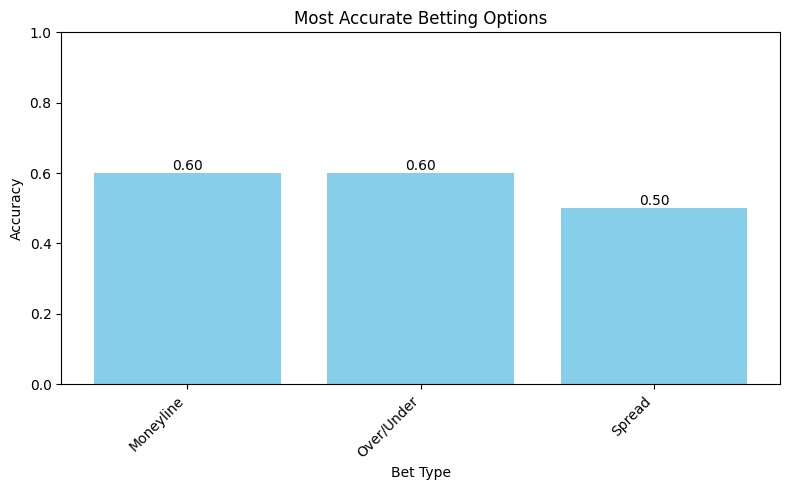

In [11]:
import matplotlib.pyplot as plt

best_accuracy = all_results.groupby("Bet Type", as_index=False)["Accuracy"].max()
best_accuracy = best_accuracy.sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(best_accuracy["Bet Type"], best_accuracy["Accuracy"], color="skyblue")
ax.set_title("Most Accurate Betting Options")
ax.set_xlabel("Bet Type")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_xticklabels(best_accuracy["Bet Type"], rotation=45, ha="right")

for idx, acc in enumerate(best_accuracy["Accuracy"]):
    ax.text(idx, acc + 0.01, f"{acc:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
summary_df = df.copy()
summary_df["Final Score"] = (
    summary_df["Away Score"].astype(int).astype(str)
    + " - "
    + summary_df["Home Score"].astype(int).astype(str)
)

summary_df = summary_df[
    [
        "Game",
        "Final Score",
        "Away Money Line",
        "Home Money Line",
        "Away Spread",
        "Home Spread",
        "Total Points",
        "Actual O/U Result",
        "Home Spread Result",
        "Home ML Result",
    ]
].rename(
    columns={
        "Away Money Line": "Away ML",
        "Home Money Line": "Home ML",
        "Actual O/U Result": "O/U Result",
        "Home Spread Result": "Spread Result",
        "Home ML Result": "ML Result",
    }
)

fig, ax = plt.subplots(figsize=(18, 8))
ax.axis("off")

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
table.auto_set_column_width(col=list(range(len(summary_df.columns))))

ax.set_title(
    "NFL Games: Final Score, Moneyline, Spread, Total Points, and Betting Results",
    pad=20,
)

plt.tight_layout()
plt.show()